Assignment 5

Data Preprocessing

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
pd.set_option('display.max_columns', None)

In [5]:
df = pd.read_csv(r'C:\Users\silpa\Downloads\Employee.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (148, 6)


,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0


In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Column names:")
print(df.columns.tolist())

Number of rows: 148
Number of columns: 6
Column names:
['Company', 'Age', 'Salary', 'Place', 'Country', 'Gender']


In [7]:
print("Data types:")
print(df.dtypes)

Data types:
Company     object
Age        float64
Salary     float64
Place       object
Country     object
Gender       int64
dtype: object


In [8]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Company     8
Age        18
Salary     24
Place      14
Country     0
Gender      0
dtype: int64


In [10]:
for column in df.columns:
    print(f"{column}")
    print("Unique values:", df[column].unique())
    print("Number of unique values:", df[column].nunique(dropna=True))

Company
Unique values: ['TCS' 'Infosys' 'CTS' nan 'Tata Consultancy Services' 'Congnizant'
 'Infosys Pvt Lmt']
Number of unique values: 6
Age
Unique values: [20. 30. 35. 40. 23. nan 34. 45. 18. 22. 32. 37. 50. 21. 46. 36. 26. 41.
 24. 25. 43. 19. 38. 51. 31. 44. 33. 17.  0. 54.]
Number of unique values: 29
Salary
Unique values: [  nan 2300. 3000. 4000. 5000. 6000. 7000. 8000. 9000. 1089. 1234. 3030.
 3045. 3184. 4824. 5835. 7084. 8943. 8345. 9284. 9876. 2034. 7654. 2934.
 4034. 5034. 8202. 9024. 4345. 6544. 6543. 3234. 4324. 5435. 5555. 8787.
 3454. 5654. 5009. 5098. 3033.]
Number of unique values: 40
Place
Unique values: ['Chennai' 'Mumbai' 'Calcutta' 'Delhi' 'Podicherry' 'Cochin' nan 'Noida'
 'Hyderabad' 'Bhopal' 'Nagpur' 'Pune']
Number of unique values: 11
Country
Unique values: ['India']
Number of unique values: 1
Gender
Unique values: [0 1]
Number of unique values: 2


In [11]:
print("Statistical summary of numerical columns:")
display(df.describe())

Statistical summary of numerical columns:


,Age,Salary,Gender
count,130.000000,124.000000,148.000000
mean,30.484615,5312.467742,0.222973
std,11.096640,2573.764683,0.417654
min,0.000000,1089.000000,0.000000
25%,22.000000,3030.000000,0.000000
50%,32.500000,5000.000000,0.000000
75%,37.750000,8000.000000,0.000000
max,54.000000,9876.000000,1.000000


In [12]:
print("Statistical summary including categorical columns:")
display(df.describe(include='all'))

Statistical summary including categorical columns:


,Company,Age,Salary,Place,Country,Gender
count,140,130.000000,124.000000,134,148,148.000000
unique,6,NaN,NaN,11,1,NaN
top,TCS,NaN,NaN,Mumbai,India,NaN
freq,53,NaN,NaN,37,148,NaN
mean,NaN,30.484615,5312.467742,NaN,NaN,0.222973
std,NaN,11.096640,2573.764683,NaN,NaN,0.417654
min,NaN,0.000000,1089.000000,NaN,NaN,0.000000
25%,NaN,22.000000,3030.000000,NaN,NaN,0.000000
50%,NaN,32.500000,5000.000000,NaN,NaN,0.000000
75%,NaN,37.750000,8000.000000,NaN,NaN,0.000000


In [13]:
# Convert column names to lowercase for consistency
df.columns = df.columns.str.strip().str.lower()

In [14]:
print("Renamed columns:")
print(df.columns.tolist())

Renamed columns:
['company', 'age', 'salary', 'place', 'country', 'gender']


In [15]:
# Standardize inconsistent/inappropriate categorical values
df['company'] = df['company'].replace({
    'Tata Consultancy Services': 'TCS',
    'Infosys Pvt Lmt': 'Infosys',
    'Congnizant': 'Cognizant',
    'CTS': 'Cognizant'
})

In [16]:
df['place'] = df['place'].replace({
    'Podicherry': 'Pondicherry',
    'Calcutta': 'Kolkata'
})

In [17]:
# Replace Age = 0 with NaN
zero_age_count = (df['age'] == 0).sum()
df['age'] = df['age'].replace(0, np.nan)

In [18]:
print("Number of Age values equal to 0 replaced by NaN:", zero_age_count)

Number of Age values equal to 0 replaced by NaN: 6


In [19]:
print("Missing values after standardization:")
print(df.isnull().sum())

Missing values after standardization:
company     8
age        24
salary     24
place      14
country     0
gender      0
dtype: int64


In [20]:
# Remove duplicate rows
duplicate_count = df.duplicated().sum()
print("Duplicate rows before removal:", duplicate_count)

Duplicate rows before removal: 4


In [21]:
df = df.drop_duplicates().reset_index(drop=True)

In [22]:
print("Shape after removing duplicates:", df.shape)
print("Duplicate rows after removal:", df.duplicated().sum())

Shape after removing duplicates: (144, 6)
Duplicate rows after removal: 0


In [23]:
def find_outliers_iqr(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return q1, q3, iqr, lower, upper, outliers

In [24]:
for column in ['age', 'salary']:
    q1, q3, iqr, lower, upper, outliers = find_outliers_iqr(df, column)
    print(f"\nColumn: {column}")
    print("Q1:", q1)
    print("Q3:", q3)
    print("IQR:", iqr)
    print("Lower bound:", lower)
    print("Upper bound:", upper)
    print("Number of outliers:", len(outliers))


Column: age
Q1: 23.0
Q3: 40.0
IQR: 17.0
Lower bound: -2.5
Upper bound: 65.5
Number of outliers: 0

Column: salary
Q1: 3030.0
Q3: 8000.0
IQR: 4970.0
Lower bound: -4425.0
Upper bound: 15455.0
Number of outliers: 0


In [25]:
# Visualize numerical distributions for outlier inspection
plt.figure(figsize=(8, 4))

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Axes: >

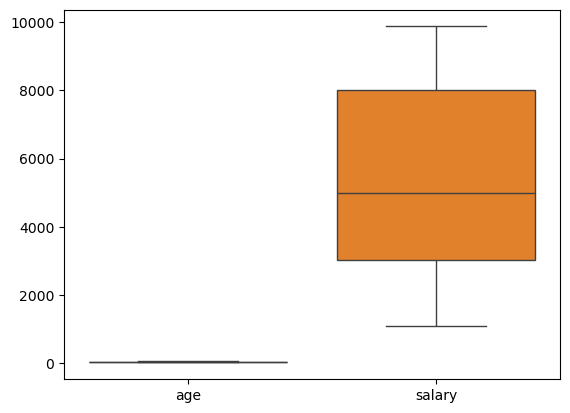

In [26]:
sns.boxplot(data=df[['age', 'salary']])

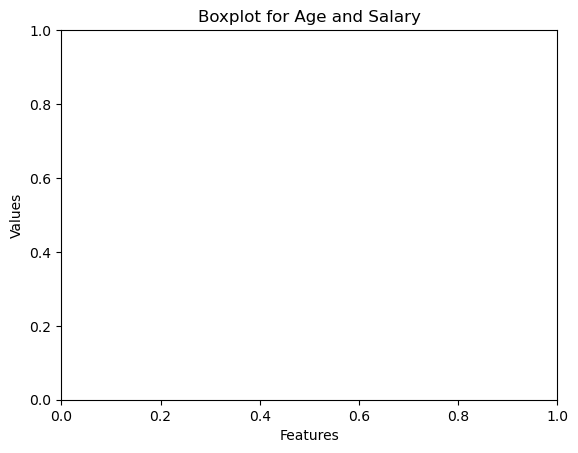

In [27]:
plt.title('Boxplot for Age and Salary')
plt.xlabel('Features')
plt.ylabel('Values')
plt.show()

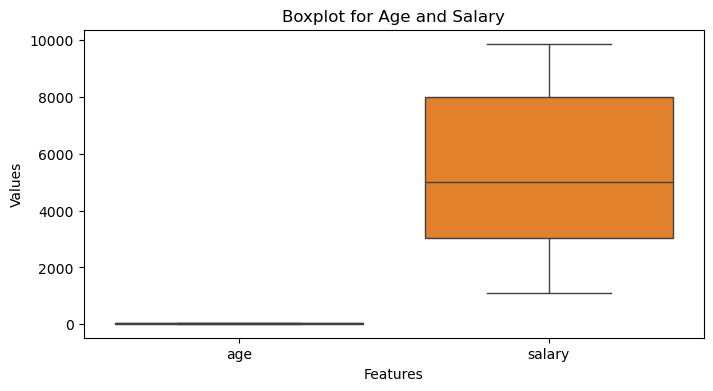

In [28]:
# Visualize numerical distributions for outlier inspection
plt.figure(figsize=(8, 4))
sns.boxplot(data=df[['age', 'salary']])
plt.title('Boxplot for Age and Salary')
plt.xlabel('Features')
plt.ylabel('Values')
plt.show()

In [29]:
print("Missing values before treatment:")
print(df.isnull().sum())

Missing values before treatment:
company     8
age        23
salary     23
place      14
country     0
gender      0
dtype: int64


In [30]:
# Categorical columns: fill with mode
for column in ['company', 'place']:
    df[column] = df[column].fillna(df[column].mode()[0])

In [31]:
# Numerical columns: fill with median
for column in ['age', 'salary']:
    df[column] = df[column].fillna(df[column].median())

In [32]:
print("Missing values after treatment:")
print(df.isnull().sum())

Missing values after treatment:
company    0
age        0
salary     0
place      0
country    0
gender     0
dtype: int64


In [34]:
print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (144, 6)


In [35]:
filtered_df = df[(df['age'] > 40) & (df['salary'] < 5000)]

In [36]:
print("Number of records satisfying Age > 40 and Salary < 5000:", len(filtered_df))
display(filtered_df)

Number of records satisfying Age > 40 and Salary < 5000: 15


,company,age,salary,place,country,gender
21,Infosys,50.0,3184.0,Delhi,India,0
32,Infosys,45.0,4034.0,Kolkata,India,0
39,Infosys,41.0,3000.0,Mumbai,India,0
50,Infosys,41.0,3000.0,Chennai,India,0
57,Infosys,51.0,3184.0,Hyderabad,India,0
68,Infosys,43.0,4034.0,Mumbai,India,0
75,Infosys,44.0,3000.0,Cochin,India,0
85,Infosys,41.0,3000.0,Delhi,India,0
92,Infosys,54.0,3184.0,Mumbai,India,0
103,Infosys,44.0,4034.0,Delhi,India,0


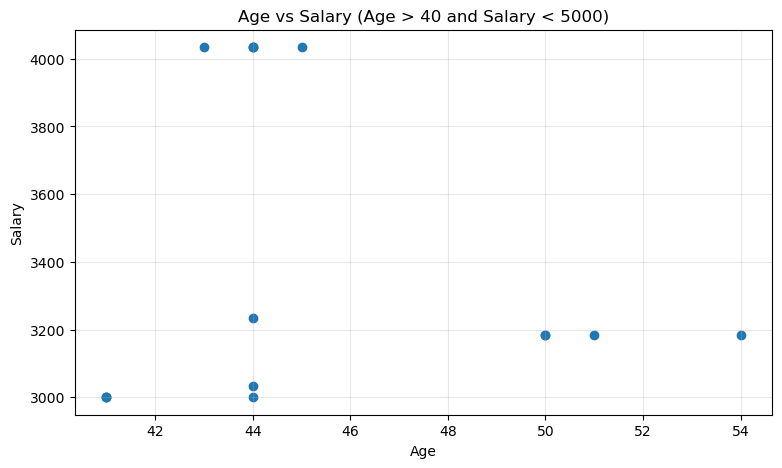

In [37]:
plt.figure(figsize=(9, 5))
plt.scatter(filtered_df['age'], filtered_df['salary'])
plt.xlabel('Age')
plt.ylabel('Salary')
plt.title('Age vs Salary (Age > 40 and Salary < 5000)')
plt.grid(True, alpha=0.3)
plt.show()

In [38]:
place_counts = df['place'].value_counts()

In [39]:
print("Employee count by place:")
display(place_counts.to_frame('Employee Count'))

Employee count by place:


,Employee Count
place,
Mumbai,48
Kolkata,32
Chennai,14
Delhi,14
Cochin,13
Noida,8
Hyderabad,8
Pondicherry,3
Pune,2


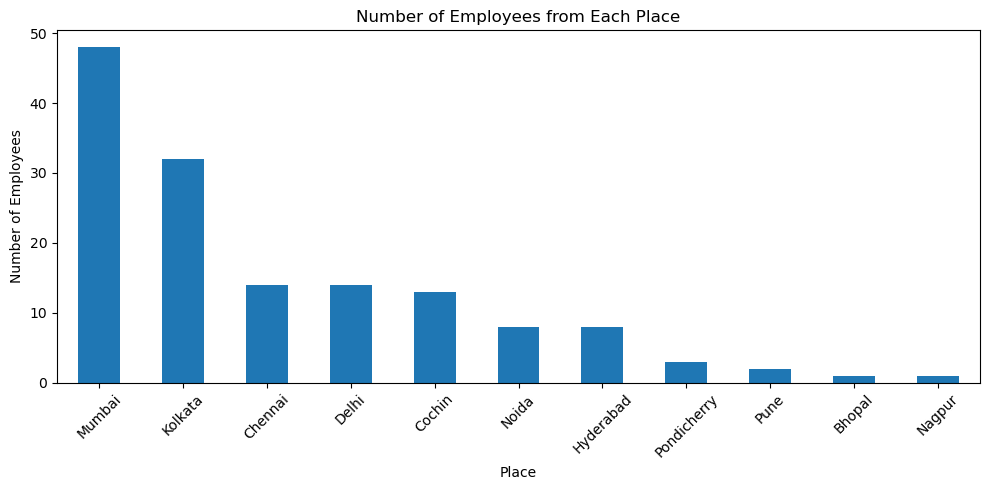

In [40]:
plt.figure(figsize=(10, 5))
place_counts.plot(kind='bar')
plt.xlabel('Place')
plt.ylabel('Number of Employees')
plt.title('Number of Employees from Each Place')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [41]:
from sklearn.preprocessing import LabelEncoder

In [42]:
encoded_df = df.copy()

In [43]:
# One-hot encoding
encoded_df = pd.get_dummies(
    encoded_df,
    columns=['company', 'place'],
    drop_first=False,
    dtype=int
)

In [44]:
# Label encoding for country
label_encoder = LabelEncoder()
encoded_df['country'] = label_encoder.fit_transform(encoded_df['country'])

In [45]:
print("Encoded dataset:")
display(encoded_df.head())

Encoded dataset:


,age,salary,country,gender,company_Cognizant,company_Infosys,company_TCS,place_Bhopal,place_Chennai,place_Cochin,place_Delhi,place_Hyderabad,place_Kolkata,place_Mumbai,place_Nagpur,place_Noida,place_Pondicherry,place_Pune
0,20.0,5000.0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0
1,30.0,5000.0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0
2,35.0,2300.0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0
3,40.0,3000.0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0
4,23.0,4000.0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0


In [48]:
print("Encoded columns:")
print(encoded_df.columns.tolist())

Encoded columns:
['age', 'salary', 'country', 'gender', 'company_Cognizant', 'company_Infosys', 'company_TCS', 'place_Bhopal', 'place_Chennai', 'place_Cochin', 'place_Delhi', 'place_Hyderabad', 'place_Kolkata', 'place_Mumbai', 'place_Nagpur', 'place_Noida', 'place_Pondicherry', 'place_Pune']


In [49]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [50]:
# Select all numerical/encoded features
feature_columns = encoded_df.columns.tolist()

In [51]:
# StandardScaler
standard_scaler = StandardScaler()
standard_scaled = pd.DataFrame(
    standard_scaler.fit_transform(encoded_df[feature_columns]),
    columns=feature_columns
)

In [52]:
print("StandardScaler result:")
display(standard_scaled.head())

StandardScaler result:


,age,salary,country,gender,company_Cognizant,company_Infosys,company_TCS,place_Bhopal,place_Chennai,place_Cochin,place_Delhi,place_Hyderabad,place_Kolkata,place_Mumbai,place_Nagpur,place_Noida,place_Pondicherry,place_Pune
0,-1.484676,-0.100827,0.0,-0.534522,-0.588043,-0.67420,1.150035,-0.083624,3.047247,-0.315018,-0.328165,-0.242536,-0.534522,-0.707107,-0.083624,-0.242536,-0.145865,-0.118678
1,-0.267174,-0.100827,0.0,-0.534522,-0.588043,1.48324,-0.869539,-0.083624,-0.328165,-0.315018,-0.328165,-0.242536,-0.534522,1.414214,-0.083624,-0.242536,-0.145865,-0.118678
2,0.341577,-1.243735,0.0,-0.534522,-0.588043,-0.67420,1.150035,-0.083624,-0.328165,-0.315018,-0.328165,-0.242536,1.870829,-0.707107,-0.083624,-0.242536,-0.145865,-0.118678
3,0.950328,-0.947426,0.0,-0.534522,-0.588043,1.48324,-0.869539,-0.083624,-0.328165,-0.315018,3.047247,-0.242536,-0.534522,-0.707107,-0.083624,-0.242536,-0.145865,-0.118678
4,-1.119426,-0.524127,0.0,-0.534522,-0.588043,-0.67420,1.150035,-0.083624,-0.328165,-0.315018,-0.328165,-0.242536,-0.534522,1.414214,-0.083624,-0.242536,-0.145865,-0.118678


In [53]:
# MinMaxScaler
minmax_scaler = MinMaxScaler()
minmax_scaled = pd.DataFrame(
    minmax_scaler.fit_transform(encoded_df[feature_columns]),
    columns=feature_columns
)

In [54]:
print("MinMaxScaler result:")
display(minmax_scaled.head())

MinMaxScaler result:


,age,salary,country,gender,company_Cognizant,company_Infosys,company_TCS,place_Bhopal,place_Chennai,place_Cochin,place_Delhi,place_Hyderabad,place_Kolkata,place_Mumbai,place_Nagpur,place_Noida,place_Pondicherry,place_Pune
0,0.081081,0.445089,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.351351,0.445089,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.486486,0.137817,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.621622,0.217480,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.162162,0.331285,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
